<a href="https://colab.research.google.com/github/sehy1420-art/OTmetricSurvey_repo/blob/main/KmeansClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# $K$-Means Clustering Algorithm in Graph Machine Learning

The topic of the Research Data Foundations Camp final project is related to graph machine learning, specifically known as the $K$-means clustering algorithm. The $K$-means clustering algorithm is an unsupervised machine learning algorithm that partitions a dataset into $K$ distinct, non-overlapping clusters. It is an iterative algorithm that assigns data points to the nearest centroid (mean) and updating centroids to minimize within-cluster sum of squared errors (distance). Namely, the algorithm steps are as follows:

1. **Initialization:** choose $K$ initial centroids (means) of the sample randomly;
2. **Assigning:** Assign each data point to the closest centroid with respect to the Euclidean distance;
3. **Update:** Calculate the new centroid for each cluster;
4. **Iteration:** Iterate 2 and 3 ultil centroids no longer change (convergence).

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from sklearn.datasets import make_blobs
from IPython.display import HTML

# 1. Setup Data and Parameters
X, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.30, random_state=0)
K = 4
centroids = X[np.random.choice(X.shape[0], K, replace=False)]

fig, ax = plt.subplots(figsize=(8, 6))

def animate(i):
    global centroids
    ax.clear()

    # Step A: Cluster Assignment
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)

    # Step B: Centroid Update
    new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])

    # Plotting
    colors = ['r', 'g', 'b', 'y']
    for k in range(K):
        ax.scatter(X[labels == k, 0], X[labels == k, 1], c=colors[k], s=30, alpha=0.5)
        ax.scatter(centroids[k, 0], centroids[k, 1], c='black', marker='x', s=200, lw=3)

    ax.set_title(f'K-Means Iteration {i+1}')
    centroids = new_centroids
    return ax,

# 2. Create Animation
# We use 'blit=False' because we are clearing the axis each frame
ani = animation.FuncAnimation(fig, animate, frames=10, interval=1000, repeat=False)

# 3. Display in Colab
plt.close() # Prevents duplicate static plot from showing
HTML(ani.to_jshtml())




# 1. Question and Hypothesis



## Question: how to measure the distance between graphs?

Typical $K$-means clustering deals with the set of "points", but we could go and ask the following question: "what if we have a set of "networks", or "graphs" instead of points? Formally, a graph is a tuple $G=(V,E)$, consisting of a set $V$ of nodes (entities) and a set $E$ of edges (relationship). Graphs are commonly used in data modelling because they intuitively represent complex, highly connected real-world relationships, unlike tabulated data. Both nodes and edges in a graph enable fast, efficient interpretation of real-world data.

The fundamental bottleneck is that the graph distance is not "intuitive": there is no natural way of measuring a distance (for example, are we measuring distance between the farthest nodes in two graphs? Closest nodes? What about other nodes that are neither the farthest nor the closes to each other?) The graph distance proposed by Chowdhury and Memoli in 2018 is non-trivial and NP-hard to compute. Hence, many other distances compares the embedding of graphs, such as a vector or a matrix (adjacency matrix, Laplacian matrix, normalized Laplacian matrix). However, such distances cannot compare networks of different number of nodes and are not scalable to large graphs.


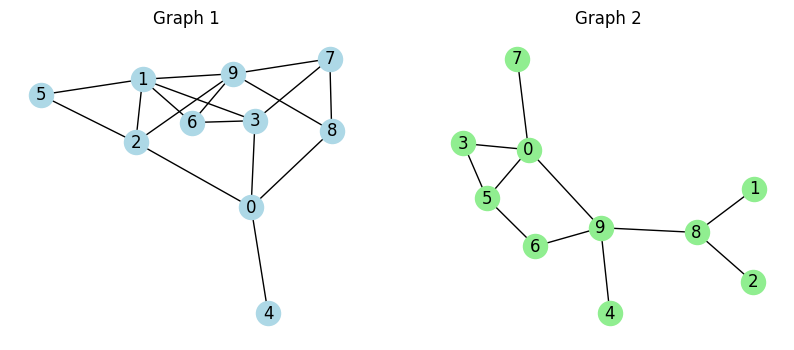

Adjacency Matrix 1:
[[0. 0. 1. 1. 1. 0. 0. 0. 1. 0.]
 [0. 0. 1. 1. 0. 1. 1. 0. 0. 1.]
 [1. 1. 0. 0. 0. 1. 0. 0. 0. 1.]
 [1. 1. 0. 0. 0. 0. 1. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 1. 1.]
 [1. 0. 0. 0. 0. 0. 0. 1. 0. 1.]
 [0. 1. 1. 0. 0. 0. 1. 1. 1. 0.]]
Adjacency Matrix 2:
[[0. 0. 0. 1. 0. 1. 0. 1. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 1. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1. 0. 1. 0. 1. 0.]]
Frobenius Distance: 6.6332495807108


In [7]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Define number of nodes and edge probability
n, p = 10, 0.3

# Generate two random graphs
G1 = nx.gnp_random_graph(n, p, seed=42)
G2 = nx.gnp_random_graph(n, p, seed=24)

# Visualize both graphs
plt.figure(figsize=(10, 4))
plt.subplot(121), nx.draw(G1, with_labels=True, node_color='lightblue'), plt.title("Graph 1")
plt.subplot(122), nx.draw(G2, with_labels=True, node_color='lightgreen'), plt.title("Graph 2")
plt.show()

# Convert G1 to adjacency matrices (as NumPy arrays)
A1 = nx.to_numpy_array(G1)
print("Adjacency Matrix 1:")
print(A1[:10, :10])

# Convert G2 to adjacency matrices (as NumPy arrays)
A2 = nx.to_numpy_array(G2)
print("Adjacency Matrix 2:")
print(A2[:10, :10])

# Compute Frobenius distance
fro_dist = np.linalg.norm(A1 - A2, ord='fro')
print(f"Frobenius Distance: {fro_dist}")

## Wasserstein Metric
The distance that I will use in my project is called the **Wasserstein metric** from optimal transportation theory, which is a metric between probablity distributions. Formally, let $\mu$ and $\nu$ be probability distributions defined on some metric space $(X,d)$, then the $p$-Wasserstein metric is defined by
$$
W_p(\mu,\nu)=\bigg(\inf_{\pi\in \Pi(\mu,\nu)}\int_{X\times X} d(x,y)^pd\pi(x,y)\bigg)^{\frac{1}{p}}.
$$
The set $\Pi(\mu,\nu)$ is the collection of all joint distributions whose marginals are $\mu$ and $\nu$.

In my project, I will only work In discrete setting, that is, when two measures $\mu=\frac{1}{n}\sum_{i=1}^n\delta_{x_i}$ and $\nu=\frac{1}{m}\sum_{j=1}^m\delta_{y_j}$ are discrete measures (or point clouds). Let $C=[C_{ij}]$ be the cost matrix (matrix whose entries correspond to the cost of moving mass from bin $i$ to bin $j$) and $\pi=[\pi_{ij}]$ be the transport plan, or the coupling (matrix whose entries correspond to the amount of mass transported from bin $i$ to bin $j$), then
$$
W_p(\mu,\nu)=\bigg(\inf_{\pi\in \mathbb{R}^{n\times m}}\sum_{i,j}C_{ij}\pi_{ij}\bigg)^{\frac{1}{p}},\quad\text{s.t. }\forall i\in [n].\forall j\in [m],\:\pi_{ij}\geq 0,\:\sum_j\pi_{ij}=x_i,\:\sum_i\pi_{ij}=y_j.
$$

The $W_p$ between measures that has at most $n$ many supports has $O(n^3\log n)$ time complexity, so directly applying the definition of $W_p$ is computationally intractable for large networks. It is well-known that the $W_p$ has a closed-form expression in one dimension. Namely, if $\mu=\frac{1}{n}\sum_{i=1}^n\delta_{x_i}$ and $\nu=\frac{1}{m}\sum_{j=1}^m\delta_{y_j}$, with $x_i,y_j\in \mathbb{R}$ for all $i\in [n]$ and $j\in [m]$, then
$$
W_1(\mu,\nu)=\int_\mathbb{R}|F_\mu(t)-F_\nu(t)|dt=\int_\mathbb{R}\bigg|\frac{1}{n}\sum_{i=1}^n \chi_{[x_i,\infty)}(t)-\frac{1}{m}\sum_{j=1}^m \chi_{[y_j,\infty)}(t)\bigg|dt,
$$
where $F_\mu$ and $F_\nu$ are the cumulative distribution functions (CDFs) of $\mu$ and $\nu$, respectively (which are measurable simple functions in this case) and $\chi_A$ is a characteristic function on a measurable set $A$. The formula seems complicated, but it is just the sum of all rectangles between two CDFs. There is a closed form for $W_p$ when $p>1$ in terms of the quantile function, but I will omit that form. I won't get into further theoretical details, since it is sufficient for the reader to know that $W_p$ measures a distance between two probability distributions.

## Graph as Probability Distribution

Recall the objective of my project: using $W_p$ as a distance between graphs in the $K$-mean clustering algorithm. That is, we need to somehow embed a graph to a probability distribution. The simplest way is to take the probability distribution of the node features, such as degree, clustering coefficient, graphlet counts, etc. If we set $x_i$ and $y_j$ in $\mu=\frac{1}{n}\sum_{i=1}^n\delta_{x_i}$ and $\nu=\frac{1}{m}\sum_{j=1}^m\delta_{y_j}$ as node features, then we get network embedding to a probability vector, or a histogram.

The following Python code visualizes an Erdős-Rényi random graph with 1000 nodes and 0.01 probability of edge formation between two nodes and create a histogram of the empirical measure induced by the graph. The vertical axis corresponds to the degree of each node, that is, the number of incident edges at a node, and the horizontal axis corresponds to the normalized number of nodes that has a degree.

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8069/1158688976.py:25: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Node Density $\\frac{1}{n}\sum \delta_{x_i}$')


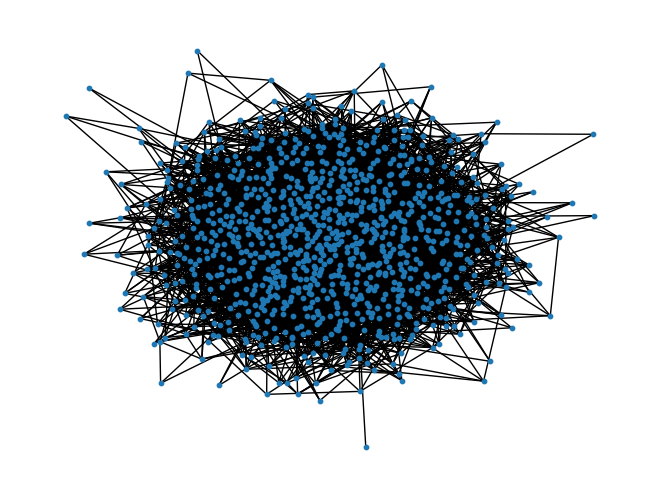

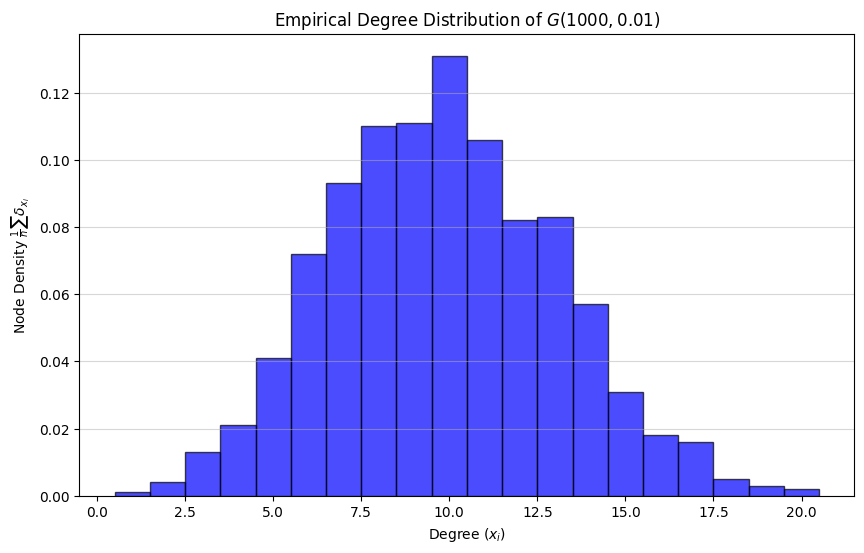

In [34]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Parameters
n = 1000  # Number of nodes
p = 0.01 # Probability of edge creation (average degree = n*p)

# 1. Generate Erdős-Rényi Graph
G = nx.erdos_renyi_graph(n, p)

# 2. Extract degrees x_i for each node
degrees = [d for n, d in G.degree()]

# 3. Visualize the Graph Structure (optional for large n)
nx.draw(G, node_size=10)
plt.show()

# 4. Visualize the Histogram of the Empirical Measure
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=range(min(degrees), max(degrees) + 2),
         density=True, alpha=0.7, color='blue', edgecolor='black', align='left')
plt.title(f'Empirical Degree Distribution of $G({n}, {p})$')
plt.xlabel('Degree ($x_i$)')
plt.ylabel('Node Density $\\frac{1}{n}\sum \delta_{x_i}$')
plt.grid(axis='y', alpha=0.5)

# Optional: Add theoretical Poisson distribution line for comparison
# from scipy.stats import poisson
# x_axis = np.arange(0, max(degrees)+1)
# plt.plot(x_axis, poisson.pmf(x_axis, n*p), 'r-', label='Theoretical Poisson')
# plt.legend()
# plt.show()


## Wasserstein Metric Between Graphs

Now, we will use the closed form of the Wasserstein metric to measure the distance between two graphs. As an example, we take two random graphs with different number of nodes and graph topology.

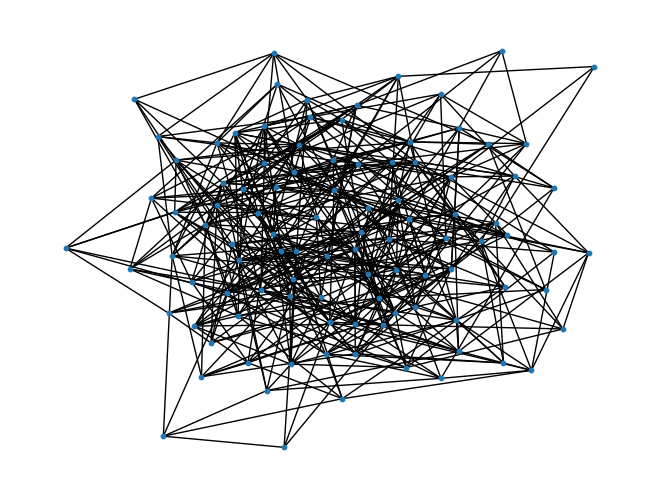

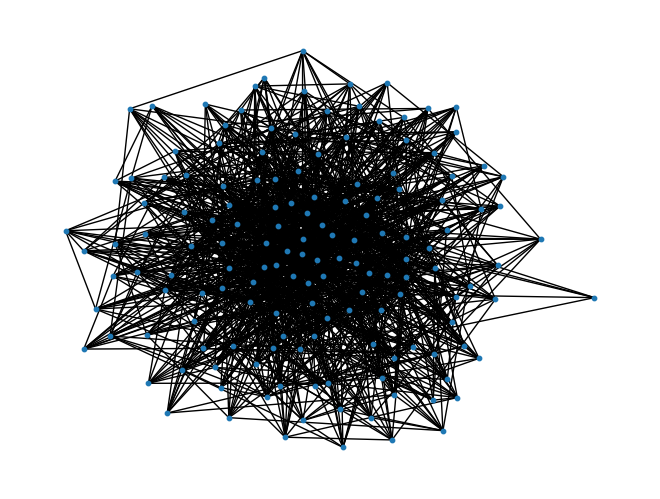

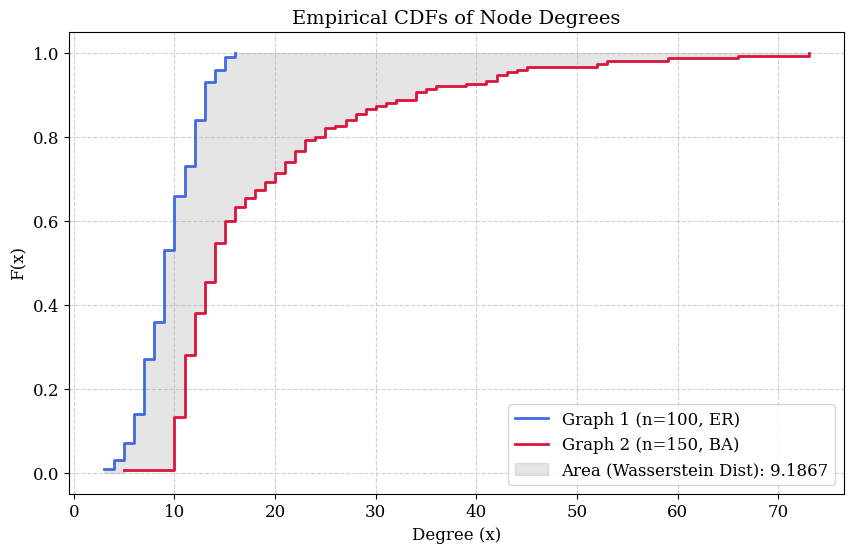

In [41]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Add these lines to disable LaTeX rendering
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'dejavusans'

def get_ecdf(data):
    """ Compute the empirical cumulative distribution function (ECDF) at x and y."""
    x = np.sort(data)
    n = x.size
    y = np.arange(1, n + 1) / n
    return x, y

def evaluate_ecdf(x_grid, x_data, y_data):
    """Compute the value of ECDF at x"""
    indices = np.searchsorted(x_data, x_grid, side='right') - 1
    y_vals = np.zeros_like(x_grid, dtype=float)
    mask = indices >= 0
    y_vals[mask] = y_data[indices[mask]]
    return y_vals

# 1. Generate two graphs with different number of nodes and graph topology
G1 = nx.erdos_renyi_graph(n=100, p=0.1, seed=42)     # Erdos-Renyi model
G2 = nx.barabasi_albert_graph(n=150, m=10, seed=42)   # Barabasi-Albert model
nx.draw(G1, node_size=10)
plt.show()
nx.draw(G2, node_size=10)
plt.show()

# 2. Extract node degree(x_i) for Empirical Measure
deg1 = np.array([d for _, d in G1.degree()])
deg2 = np.array([d for _, d in G2.degree()])

# 3. Calculate ECDF
x1, y1 = get_ecdf(deg1)
x2, y2 = get_ecdf(deg2)

# 4. Generate a common x-axis for plotting both ECDFS (union of all node degrees from G1 and G2))
all_x = np.unique(np.concatenate([deg1, deg2]))
y1_grid = evaluate_ecdf(all_x, x1, y1)
y2_grid = evaluate_ecdf(all_x, x2, y2)

# Calculate the area between two CDFs (W1 Distance)
area = np.sum(np.abs(y1_grid[:-1] - y2_grid[:-1]) * np.diff(all_x))

# 5. Visualization
plt.figure(figsize=(10, 6))
plt.step(x1, y1, where='post', label=f'Graph 1 (n=100, ER)', color='royalblue', lw=2)
plt.step(x2, y2, where='post', label=f'Graph 2 (n=150, BA)', color='crimson', lw=2)

# Fill the area between two CDFS
plt.fill_between(all_x, y1_grid, y2_grid, step='post', color='gray', alpha=0.2,
                 label=f'Area (Wasserstein Dist): {area:.4f}')

plt.title('Empirical CDFs of Node Degrees', fontsize=14)
plt.xlabel('Degree (x)', fontsize=12)
plt.ylabel('F(x)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

From our simple numerical experiment, the $W_1$ metric is independent of number of nodes, and the computation is very fast; in fact, the computational complexity of the closed form of the $W_1$ metric is $O(n\log n)$. Hence, the $W_1$ metric can be used to measure graphs of different number of nodes!

## Hypothesis: graphs belong to same cluster have similar topological properties

Now we have seen the $W_1$ metric successfully measure the distance between two graphs, we can use the $W_1$ metric instead of the Euclidean metric in the $K$-means clustering algorithm to cluster set of graphs, not points.

In this project, I take 8 datasets under infrastructure networks category from Network Data Repository: https://networkrepository.com/inf.php. Each dataset contains a global network statistics summary, such as number of nodes, edges, degree, graphlet counts, etc. I hypothesize the following. If we are given a collection of graphs $\mathcal{G}=\{G_1,\cdots,G_N\}$ and do the $K$-means clustering algorithm with respect to the $W_1$ metric, then graphs belong to the same cluster have similar topological properties.

# Python Code and Analysis Outputs
- TensorFlow 시작하기
- 신경망 개발 및 학습시키기
- TPU로 실험하기
- AI 연구 보급하기
- 튜토리얼 만들기

머신러닝 적용 사례를 보여 주는 Colab 메모장 샘플을 확인하려면 아래 <a href="#machine-learning-examples">머신러닝 예시</a>를 참조하세요.

<div class="markdown-google-sans">

## 추가 리소스

### Colab에서 메모장 사용하기

</div>

- [Colab 개요](/notebooks/basic_features_overview.ipynb)
- [Markdown 가이드](/notebooks/markdown_guide.ipynb)
- [라이브러리 가져오기 및 종속 항목 설치하기](/notebooks/snippets/importing_libraries.ipynb)
- [GitHub에서 노트 저장 및 로드하기](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [대화형 양식](/notebooks/forms.ipynb)
- [대화형 위젯](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### 데이터로 작업하기
</div>

- [데이터 로드: 드라이브, 스프레드시트, Google Cloud Storage](/notebooks/io.ipynb)
- [차트: 데이터 시각화하기](/notebooks/charts.ipynb)
- [BigQuery 시작하기](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### 머신러닝

<div>

Google의 온라인 머신러닝 과정을 비롯해 머신러닝과 관련된 일부 노트북입니다. 자세한 내용은 <a href="https://developers.google.com/machine-learning/crash-course/">전체 과정 웹사이트</a>를 참고하세요.
- [Pandas DataFrame 소개](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Pandas를 가속화하는 RAPIDS cuDF 소개](https://nvda.ws/rapids-cudf)
- [cuML의 가속기 모드 시작하기](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### 가속 하드웨어 사용하기
</div>

- [Flax NNX API를 사용하여 MNIST 데이터 세트에서 필기 입력 숫자를 분류하도록 CNN 학습시키기](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [JAX로 이미지 분류를 위한 Vision Transformer&#40;ViT&#41; 학습시키기](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [JAX를 사용한 Transformer 언어 모델 기반 텍스트 분류](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### 추천 예시

</div>

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">JAX AI 스택으로 miniGPT 언어 모델 학습시키기</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">Tunix를 사용한 LLM용 LoRA/QLoRA 미세 조정</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">LoRA 및 QLoRA를 사용한 Gemma의 Parameter-Efficient Fine-Tuning&#40;PEFT&#41;</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Hugging Face Transformers 체크포인트 로드</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">Keras의 8비트 정수 양자화</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">간단한 Transformer 모델을 사용한 Float8 학습 및 추론</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">KerasHub로 처음부터 Transformer 사전 학습시키기</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">단순 MNIST 합성곱 신경망</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Keras 3를 사용해 처음부터 이미지 분류 구현</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">KerasHub를 사용한 이미지 분류</a>
